# Experiment 4.2 — Integrating Feature Extractors into ICP

Notebook 4.1 characterised descriptors on their own terms and found them informative: at mild
degradation a true pair is each other's nearest neighbour in descriptor space far more often
than position alone would manage. It deliberately left open *how* that information reaches the
matcher.

Two decisions remain, and this notebook takes them in order.

| § | Question |
|---|---|
| 1 | **Where** do features enter the E-step — re-weighting candidates, or selecting them? |
| 2 | **How much** weight should they carry relative to position? |

Section 2 is the substantial one. It sweeps `beta` against the two things that ought to move
its optimum in opposite directions — how *unreliable* the descriptor is, and how *misaligned*
the clouds are — and ends with the case for annealing it rather than fixing it.

In [1]:
import sys
sys.path.insert(0, '../src')

from dataclasses import dataclass
from typing import Any, Literal

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from tabulate import tabulate
from tqdm import tqdm

from algebra_utils import rotation_with_angle
from error_metrics import correspondence_margin, mutual_nearest_neighbor_fraction
from experiment_runner import MultiSeedSyntheticICPResult, fit_multi_seed
from feature_extractor import (
    FeatureExtractor,
    GeometricFeatureExtractor,
    RobustGeometricFeatureExtractor,
)
from icp import ICP, ICPCallback, SigmaAnnealingCallback
from matcher import GaussianMatcher, NearestNeighborMatcher
from point_cloud import PointCloud
from synthetic import (
    PerfectObserver,
    PointCloudObserver,
    SyntheticExperiment,
    invert_correspondence,
    make_correspondence_pair,
)
from transformation import RigidTransformation
from visualization import SweepVisualizer

plt.style.use('seaborn-v0_8-whitegrid')

CLOUD_STYLE = 'clustered'
N_SEEDS = 50
MAX_ITER = 400
TOL = 1e-6
SIGMA_INIT, SIGMA_FINAL = 20.0, 1.0
MATCHER_K = 10   # candidates the Gaussian matcher averages over
ALPHA = 5.0      # additive mode: cosine-similarity weight
FE_K = 40        # neighbourhood size, from notebook 4.1

ICP_N_POINTS = 500
ICP_GEN_KWARGS: dict[str, Any] = dict(n=ICP_N_POINTS, t_scale=8.0, style=CLOUD_STYLE)

CHAR_N_POINTS = 2000
CHAR_SEEDS = [0, 1, 2]
CHAR_GEN_KWARGS: dict[str, Any] = dict(n=CHAR_N_POINTS, t_scale=8.0, style=CLOUD_STYLE)

EXTRACTOR_COLORS = {'Geometric': 'tab:orange', 'Robust': 'tab:green'}
BAR_COLOR = '#2a78d6'

In [2]:
@dataclass(frozen=True)
class Variant:
    """One (matcher, feature extractor, input scheme) combination to evaluate.

    Attributes:
        label:        Short name used in plots and tables.
        matcher_kind: 'gaussian' for soft, sigma-annealed matching; 'nn' for hard.
        extractor:    Feature extractor, or None for the featureless baseline.
        mode:         How features enter the E-step — 'none', 'additive' (added to
                      log-weights) or 'append' (concatenated before the KDTree).
    """

    label: str
    matcher_kind: Literal['gaussian', 'nn']
    extractor: FeatureExtractor | None
    mode: Literal['none', 'additive', 'append']


def build_icp(variant: Variant, beta: float) -> ICP:
    """Instantiate the ICP described by a Variant.

    Args:
        variant: The combination to build.
        beta:    Feature influence for append mode.

    Returns:
        A configured ICP. Gaussian variants carry a sigma-annealing callback;
        nearest-neighbour variants have no sigma to anneal.

    Raises:
        ValueError: If the variant asks for additive mode with hard matching, which has
                    no meaning — see section 1.
    """
    feature_kwargs: dict[str, Any] = (
        {} if variant.mode == 'none' else {'feature_extractor': variant.extractor}
    )
    if variant.mode == 'additive':
        feature_kwargs |= {'feature_mode': 'additive', 'alpha': ALPHA}
    elif variant.mode == 'append':
        feature_kwargs |= {'beta': beta}

    if variant.matcher_kind == 'gaussian':
        if variant.mode == 'append':
            feature_kwargs |= {'feature_mode': 'append'}
        matcher = GaussianMatcher(sigma=SIGMA_INIT, k=MATCHER_K, **feature_kwargs)
        callbacks: list[ICPCallback] = [SigmaAnnealingCallback(SIGMA_INIT, SIGMA_FINAL, MAX_ITER)]
    else:
        if variant.mode == 'additive':
            raise ValueError('Additive mode has no nearest-neighbour analog.')
        matcher = NearestNeighborMatcher(**feature_kwargs)
        callbacks = []
    return ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL, callbacks=callbacks)


def run_variants(
    variants: list[Variant],
    observer: PointCloudObserver,
    desc: str,
    beta: float,
) -> dict[str, MultiSeedSyntheticICPResult]:
    """Fit every variant over all seeds under one observation regime.

    Args:
        variants: Combinations to fit.
        observer: Degradation applied before fitting. Rewound per variant via
                  ``reset()`` so all variants are scored on identical observations;
                  an observer's generator advances with every seed it serves, so
                  passing one straight through would let variant order pick the winner.
        desc:     Progress-bar label.
        beta:     Feature influence for append mode.

    Returns:
        Dict keyed by variant label.
    """
    return {
        variant.label: fit_multi_seed(
            build_icp(variant, beta), list(range(N_SEEDS)),
            experiment_kwargs=ICP_GEN_KWARGS, observer=observer.reset(), verbose=False,
        )
        for variant in tqdm(variants, desc=desc)
    }


def median_point_spacing(cloud: PointCloud) -> float:
    """Median distance from a point to its nearest neighbour.

    Args:
        cloud: PointCloud to measure.

    Returns:
        The median nearest-neighbour distance, the natural unit for noise and drift.
    """
    distances, _ = KDTree(cloud.points).query(cloud.points, k=2)
    return float(np.median(distances[:, 1]))


def reliability(result: MultiSeedSyntheticICPResult, tol: float) -> float:
    """Fraction of seeds that reached the global optimum rather than a wrong basin.

    Outcomes are effectively binary — a run either recovers the transformation to within
    the noise floor or lands a cloud-diameter away — so this single number carries the
    comparison and no error statistic adds to it.

    Args:
        result: One variant's multi-seed result.
        tol:    Mean-true-residual threshold. Degraded regimes need a looser value,
                since dropout leaves the two sides holding different subsets and puts a
                floor under the achievable residual.

    Returns:
        Fraction in [0, 1].
    """
    return float((np.array(result.mean_true_residuals) < tol).mean())


SPACING = median_point_spacing(SyntheticExperiment.generate(**ICP_GEN_KWARGS, seed=0).P)
CLEAN_TOL = 1e-3
DEGRADED_TOL = 0.5 * SPACING
print(f'point spacing {SPACING:.2f} | clean tol {CLEAN_TOL} | degraded tol {DEGRADED_TOL:.2f}')

point spacing 2.00 | clean tol 0.001 | degraded tol 1.00


## 1. Where do features enter — weighting, or selection?

`GaussianMatcher` offers two ways to use a descriptor.

- **Additive**: candidates are the `k` spatial nearest neighbours, found by position alone;
  cosine similarity between feature vectors is then added to their log-weights.
  `log_w += alpha * cos_sim(f_i, f_j)`.
- **Append**: the z-scored features are concatenated onto the coordinates and the KDTree is
  built in that joint space, so features take part in *finding* the candidates.

The distinction matters more than it looks. Additive mode can only re-rank what position has
already proposed; if the true correspondent is not among the `k` spatial neighbours, no feature
weight can bring it back. Append mode can retrieve a correspondent from anywhere in the cloud.

The cell below measures how often the right answer is even on the additive ballot, then
compares the two modes end to end.

In [3]:
# How often is the true correspondent among the k spatial candidates additive mode sees,
# at ICP's starting configuration (centroids aligned, orientation still wrong)?
coverage = []
for seed in range(20):
    experiment = SyntheticExperiment.generate(**ICP_GEN_KWARGS, seed=seed)
    start = RigidTransformation(
        np.eye(3), experiment.Q.points.mean(0) - experiment.P.points.mean(0),
    ).apply(experiment.P)
    _, neighbours = KDTree(experiment.Q.points).query(start.points, k=MATCHER_K)
    coverage.append((neighbours == np.arange(len(experiment.Q.points))[:, None]).any(axis=1).mean())
coverage = np.array(coverage)
print(f'True correspondent within the {MATCHER_K} spatial candidates: '
      f'median {np.median(coverage):.1%}, {int((coverage < 0.2).sum())}/20 seeds below 20%\n')

MODE_BETA = 3.0
mode_variants = [
    Variant('Soft | baseline', 'gaussian', None, 'none'),
    Variant('Soft | geo additive', 'gaussian', GeometricFeatureExtractor(k=FE_K), 'additive'),
    Variant('Soft | geo append', 'gaussian', GeometricFeatureExtractor(k=FE_K), 'append'),
    Variant('Hard | geo append', 'nn', GeometricFeatureExtractor(k=FE_K), 'append'),
]
results_mode = run_variants(mode_variants, PerfectObserver(), 'additive vs append', MODE_BETA)
print(tabulate(
    [[label, f'{reliability(r, CLEAN_TOL):.0%}', f'{np.median(r.durations_s):.2f}']
     for label, r in results_mode.items()],
    headers=['Variant', 'Reliability', 'Runtime (s)'], tablefmt='rounded_outline',
))

True correspondent within the 10 spatial candidates: median 5.5%, 20/20 seeds below 20%



additive vs append: 100%|██████████| 4/4 [01:11<00:00, 17.80s/it]

╭─────────────────────┬───────────────┬───────────────╮
│ Variant             │ Reliability   │   Runtime (s) │
├─────────────────────┼───────────────┼───────────────┤
│ Soft | baseline     │ 26%           │          0.41 │
│ Soft | geo additive │ 30%           │          0.49 │
│ Soft | geo append   │ 98%           │          0.39 │
│ Hard | geo append   │ 98%           │          0.01 │
╰─────────────────────┴───────────────┴───────────────╯


### Observations — weighting vs selection

| variant | reliability |
|---|---|
| Soft \| baseline | 26% |
| Soft \| geo additive | 30% |
| Soft \| geo append | **98%** |
| Hard \| geo append | **98%** |

**Additive mode is worth 4 points; append mode is worth 72.** With the same descriptor, the
same `k`, and the same matcher, the only difference is whether features help *choose* the
candidates or merely re-weight them afterwards — and that difference is the entire benefit.

**The candidate-coverage measurement explains it.** At ICP's starting configuration the true
correspondent is among the `k=10` spatial nearest neighbours for a median of **5.5%** of points,
and on **20 of 20 seeds** for under a fifth of them. Additive mode can only re-rank what
position already proposed, so on almost every point the correct answer is not on the ballot and
no feature weight can bring it back. Append mode builds the KDTree in the joint space, so a
correspondent can be retrieved from anywhere in the cloud.

This is a structural limit, not a tuning problem: no value of `alpha` can recover a candidate
that was never retrieved. **Append mode for the rest of this notebook.**

**Hard matching also matches soft exactly** (98% vs 98%) at roughly 50x less cost, reproducing
notebook 4.1 §1's oracle finding with a real descriptor — good features remove the problem
sigma annealing was solving.

## 2. How much weight should features carry?

With append mode settled, one parameter is left: `beta`, the influence of the whole feature
block relative to the whole position block in the joint metric (`matcher.joint_knn` scales
features by `beta * sqrt(3 / D)` so the value means the same thing at any feature width).

Two forces should push its optimum in opposite directions.

- **Descriptor reliability.** Notebook 4.1 showed degradation erodes feature agreement. The
  less trustworthy the descriptor, the *less* weight it should get — high `beta` freezes
  correspondences on features and leaves no position signal to overrule a wrong one.
- **Misalignment.** Position is only informative once the clouds are roughly aligned. The
  further apart they are, the *more* weight features should get, because nothing else can find
  a correspondence at all.

If both hold, no constant `beta` can be right for a whole run, which is the argument for
annealing it. Each is measured below: 2.1 sweeps `beta` against misalignment, 2.2 against
degradation.

### 2.1 `beta` vs. misalignment

Correspondence quality in the **joint space the matcher actually searches**, at a fixed mild
degradation, as the clouds are rotated further and further apart.

Misalignment is applied as a rotation of an exact angle about a random axis, with the centroids
brought together afterwards — ICP does the same via `init_align_centroids` before its first
iteration, so leaving the clouds metres apart would score a condition it never faces. What
remains is the rotation, which is the real difficulty.

In [4]:
BETA_VALUES = [0.0, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0]
MISALIGNMENT_DEG = [0.0, 5.0, 15.0, 45.0, 90.0, 150.0]
FIXED_NOISE, FIXED_DROPOUT = 0.15, 0.1


def alignment_scores(
    beta: float,
    angle_deg: float,
    extractor: FeatureExtractor,
    seeds: list[int] | None = None,
) -> tuple[float, float]:
    """Mutual-NN fraction and median margin in the joint space at one (beta, angle).

    Args:
        beta:      Feature influence relative to position.
        angle_deg: Misalignment applied to the target, in degrees about a random axis.
        extractor: Feature extractor in use.
        seeds:     Experiment seeds to average over. Defaults to CHAR_SEEDS.

    Returns:
        Tuple (mutual-NN fraction, median correspondence margin), averaged over seeds.
    """
    seeds = CHAR_SEEDS if seeds is None else seeds
    fractions, margins = [], []
    for seed in seeds:
        experiment = SyntheticExperiment.generate(**CHAR_GEN_KWARGS, seed=seed)
        source, target, target_to_source = make_correspondence_pair(
            experiment.P, experiment.P, dropout_prob=FIXED_DROPOUT,
            noise_std=FIXED_NOISE, rng=np.random.default_rng(seed),
        )
        correspondence = invert_correspondence(target_to_source, len(source.points))

        rotation = rotation_with_angle(angle_deg, np.random.default_rng(seed))
        centre = target.points.mean(axis=0)
        rotated = (target.points - centre) @ rotation.T + source.points.mean(axis=0)
        moved = PointCloud(rotated)

        extractor_arg = extractor if beta > 0 else None
        fractions.append(mutual_nearest_neighbor_fraction(
            source, moved, feature_extractor=extractor_arg, beta=beta,
            correspondence=correspondence,
        ))
        margins.append(float(np.median(correspondence_margin(
            source, moved, feature_extractor=extractor_arg, beta=beta,
            correspondence=correspondence,
        ))))
    return float(np.mean(fractions)), float(np.mean(margins))


extractor = GeometricFeatureExtractor(k=FE_K)
# (len(BETA_VALUES), len(MISALIGNMENT_DEG), 2) of [fraction, margin]
misalign_grid = np.zeros((len(BETA_VALUES), len(MISALIGNMENT_DEG), 2))
for i, beta in enumerate(tqdm(BETA_VALUES, desc='beta x misalignment')):
    for j, angle in enumerate(MISALIGNMENT_DEG):
        misalign_grid[i, j] = alignment_scores(beta, angle, extractor)

beta x misalignment: 100%|██████████| 8/8 [00:35<00:00,  4.41s/it]


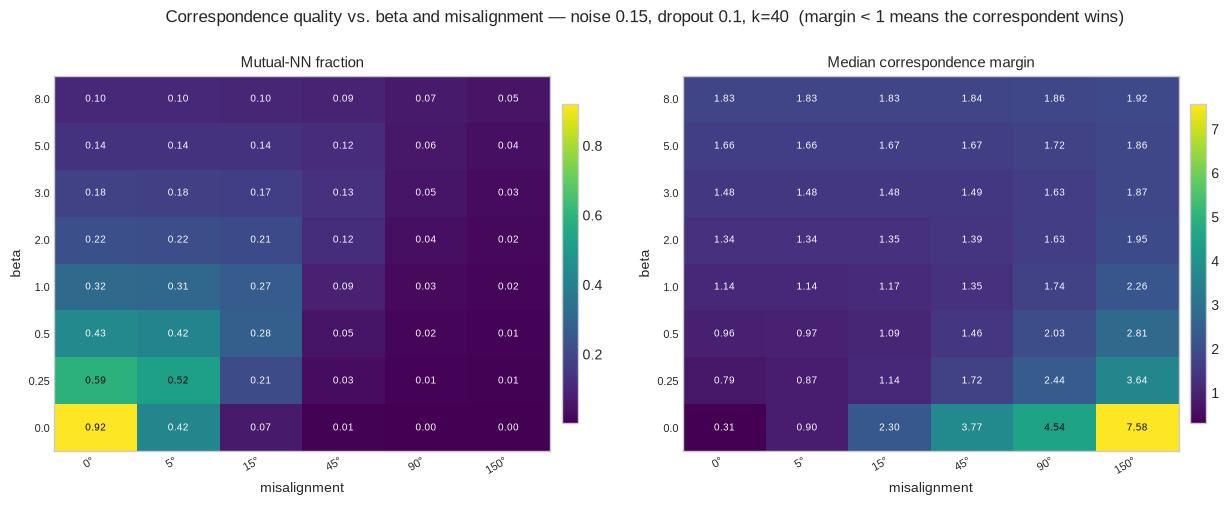

Mutual-NN fraction — rows: beta, columns: misalignment
╭────────┬───────┬───────┬───────┬───────┬───────┬────────╮
│   beta │    0° │    5° │   15° │   45° │   90° │   150° │
├────────┼───────┼───────┼───────┼───────┼───────┼────────┤
│   0    │ 0.921 │ 0.422 │ 0.068 │ 0.007 │ 0.002 │  0.002 │
│   0.25 │ 0.593 │ 0.52  │ 0.213 │ 0.031 │ 0.01  │  0.006 │
│   0.5  │ 0.434 │ 0.416 │ 0.279 │ 0.052 │ 0.018 │  0.011 │
│   1    │ 0.318 │ 0.312 │ 0.271 │ 0.086 │ 0.026 │  0.017 │
│   2    │ 0.225 │ 0.224 │ 0.21  │ 0.123 │ 0.041 │  0.021 │
│   3    │ 0.18  │ 0.178 │ 0.173 │ 0.133 │ 0.053 │  0.028 │
│   5    │ 0.137 │ 0.137 │ 0.135 │ 0.117 │ 0.062 │  0.04  │
│   8    │ 0.103 │ 0.104 │ 0.102 │ 0.095 │ 0.07  │  0.049 │
╰────────┴───────┴───────┴───────┴───────┴───────┴────────╯

Best beta per misalignment level:
╭────────────────┬─────────────┬───────╮
│ misalignment   │   best beta │   MNN │
├────────────────┼─────────────┼───────┤
│ 0°             │        0    │ 0.921 │
│ 5°             │        

In [5]:
# One heatmap per metric. Both are functions of the same (beta, misalignment) grid, so
# they sit side by side rather than as surfaces; the exact values are what get read off.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (metric_index, metric_label, fmt) in zip(axes, [
    (0, 'Mutual-NN fraction', '.2f'),
    (1, 'Median correspondence margin', '.2f'),
]):
    image = SweepVisualizer.plot_heatmap(
        ax, misalign_grid[:, :, metric_index],
        x_labels=[f'{angle:g}°' for angle in MISALIGNMENT_DEG],
        y_labels=BETA_VALUES,
        x_label='misalignment', y_label='beta',
        title=metric_label, value_format=fmt,
    )
    fig.colorbar(image, ax=ax, shrink=0.85, pad=0.02)

fig.suptitle(
    f'Correspondence quality vs. beta and misalignment — noise {FIXED_NOISE}, '
    f'dropout {FIXED_DROPOUT}, k={FE_K}  (margin < 1 means the correspondent wins)',
    y=1.0,
)
fig.tight_layout()
fig.savefig('../results/4_2_beta_vs_misalignment.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mutual-NN fraction — rows: beta, columns: misalignment')
print(tabulate(
    [[beta] + [f'{misalign_grid[i, j, 0]:.3f}' for j in range(len(MISALIGNMENT_DEG))]
     for i, beta in enumerate(BETA_VALUES)],
    headers=['beta'] + [f'{a:g}°' for a in MISALIGNMENT_DEG], tablefmt='rounded_outline',
))
print('\nBest beta per misalignment level:')
print(tabulate(
    [[f'{a:g}°', BETA_VALUES[int(np.argmax(misalign_grid[:, j, 0]))],
      f'{misalign_grid[:, j, 0].max():.3f}'] for j, a in enumerate(MISALIGNMENT_DEG)],
    headers=['misalignment', 'best beta', 'MNN'], tablefmt='rounded_outline',
))

### 2.2 `beta` vs. degradation

Section 2.1 scores correspondences at iteration 0, which cannot say where reliability peaks:
ICP does not need *good* correspondences so much as *enough* of them to start rotating, and
past that point more feature weight only displaces the position signal it needs to finish.

So this sweep measures the end-to-end quantity directly — the fraction of seeds reaching the
global optimum — against `beta` and degradation level. Hard matching, since section 1 shows it
matches the soft matcher once features are present and costs far less.

In [6]:
DEGRADATION_LEVELS: dict[str, dict[str, float]] = {
    'clean':    dict(noise_std=0.00, dropout_prob=0.0),
    'mild':     dict(noise_std=0.10, dropout_prob=0.05),
    'moderate': dict(noise_std=0.20, dropout_prob=0.10),
    'heavy':    dict(noise_std=0.40, dropout_prob=0.20),
    'severe':   dict(noise_std=0.70, dropout_prob=0.30),
}

sweep_variant = [Variant('Hard | geo append', 'nn', GeometricFeatureExtractor(k=FE_K), 'append')]

# (len(BETA_VALUES), len(DEGRADATION_LEVELS)) of reliability
reliability_grid = np.zeros((len(BETA_VALUES), len(DEGRADATION_LEVELS)))
for i, beta in enumerate(tqdm(BETA_VALUES, desc='beta x degradation')):
    if beta == 0.0:
        variants = [Variant('Hard | baseline', 'nn', None, 'none')]
    else:
        variants = sweep_variant
    for j, (level, degradation) in enumerate(DEGRADATION_LEVELS.items()):
        observer = PointCloudObserver(**degradation)
        tol = CLEAN_TOL if level == 'clean' else DEGRADED_TOL
        results = run_variants(variants, observer, f'beta={beta}, {level}', beta)
        reliability_grid[i, j] = reliability(next(iter(results.values())), tol)

beta x degradation: 100%|██████████| 8/8 [01:25<00:00, 10.67s/it]


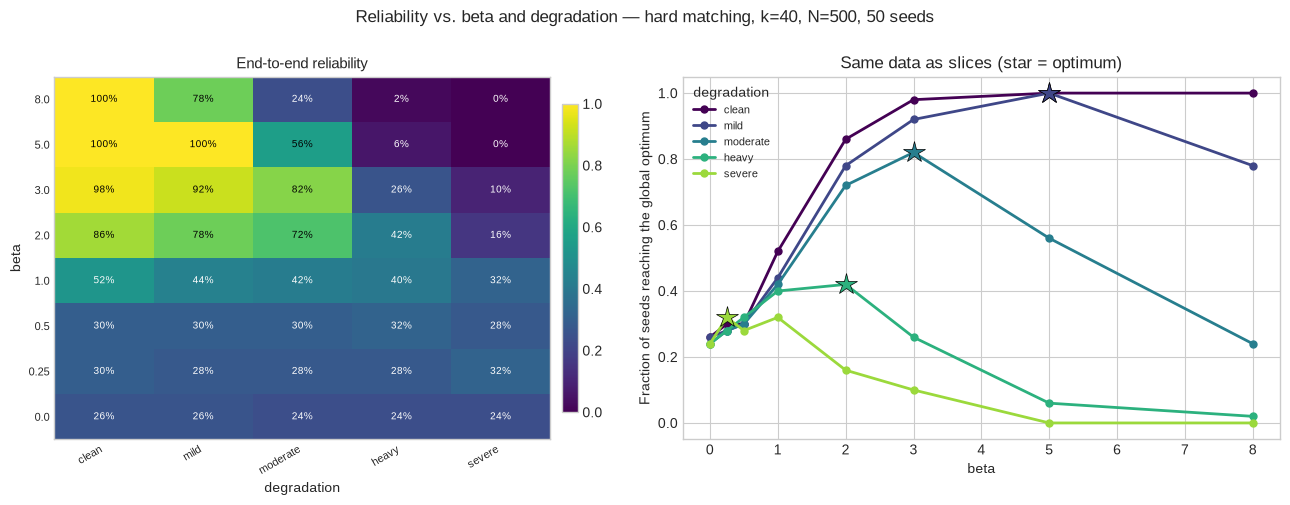

╭────────┬─────────┬────────┬────────────┬─────────┬──────────╮
│   beta │ clean   │ mild   │ moderate   │ heavy   │ severe   │
├────────┼─────────┼────────┼────────────┼─────────┼──────────┤
│   0    │ 26%     │ 26%    │ 24%        │ 24%     │ 24%      │
│   0.25 │ 30%     │ 28%    │ 28%        │ 28%     │ 32%      │
│   0.5  │ 30%     │ 30%    │ 30%        │ 32%     │ 28%      │
│   1    │ 52%     │ 44%    │ 42%        │ 40%     │ 32%      │
│   2    │ 86%     │ 78%    │ 72%        │ 42%     │ 16%      │
│   3    │ 98%     │ 92%    │ 82%        │ 26%     │ 10%      │
│   5    │ 100%    │ 100%   │ 56%        │ 6%      │ 0%       │
│   8    │ 100%    │ 78%    │ 24%        │ 2%      │ 0%       │
╰────────┴─────────┴────────┴────────────┴─────────┴──────────╯

Best beta per degradation level:
╭───────────────┬─────────────┬───────────────╮
│ degradation   │   best beta │ reliability   │
├───────────────┼─────────────┼───────────────┤
│ clean         │        5    │ 100%          │
│ mild

In [7]:
level_labels = list(DEGRADATION_LEVELS)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

image = SweepVisualizer.plot_heatmap(
    axes[0], reliability_grid,
    x_labels=level_labels, y_labels=BETA_VALUES,
    x_label='degradation', y_label='beta',
    title='End-to-end reliability',
    value_format='.0%', vmin=0.0, vmax=1.0,
)
fig.colorbar(image, ax=axes[0], shrink=0.85, pad=0.02)

# The heatmap shows where the optimum sits; the slices show how sharp it is.
ax2 = axes[1]
shades = plt.cm.viridis(np.linspace(0.0, 0.85, len(level_labels)))
for j, level in enumerate(level_labels):
    ax2.plot(BETA_VALUES, reliability_grid[:, j], marker='o', ms=5,
             color=shades[j], linewidth=2, label=level)
    best = int(np.argmax(reliability_grid[:, j]))
    ax2.plot(BETA_VALUES[best], reliability_grid[best, j], marker='*', ms=16,
             color=shades[j], markeredgecolor='black', markeredgewidth=0.5)
ax2.set_xlabel('beta')
ax2.set_ylabel('Fraction of seeds reaching the global optimum')
# A little headroom past 0 and 1: a curve sitting exactly on either bound is otherwise
# drawn half outside the axes and reads as clipped rather than saturated.
ax2.set_ylim(-0.05, 1.05)
ax2.set_title('Same data as slices (star = optimum)')
ax2.legend(fontsize=8, title='degradation')

fig.suptitle(f'Reliability vs. beta and degradation — hard matching, k={FE_K}, '
             f'N={ICP_N_POINTS}, {N_SEEDS} seeds', y=1.0)
fig.tight_layout()
fig.savefig('../results/4_2_beta_vs_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

print(tabulate(
    [[beta] + [f'{reliability_grid[i, j]:.0%}' for j in range(len(level_labels))]
     for i, beta in enumerate(BETA_VALUES)],
    headers=['beta'] + level_labels, tablefmt='rounded_outline',
))
print('\nBest beta per degradation level:')
print(tabulate(
    [[level, BETA_VALUES[int(np.argmax(reliability_grid[:, j]))],
      f'{reliability_grid[:, j].max():.0%}'] for j, level in enumerate(level_labels)],
    headers=['degradation', 'best beta', 'reliability'], tablefmt='rounded_outline',
))

### Observations — choosing `beta`

**Both predictions hold, and they point in opposite directions.**

*More misalignment favours a higher `beta`* (§2.1) — the optimum moves monotonically right:

| misalignment | 0° | 5° | 15° | 45° | 90° | 150° |
|---|---|---|---|---|---|---|
| best `beta` | 0 | 0.25 | 0.5 | 3 | 8 | 8 |

At perfect alignment position pairs 92% of points and any feature weight makes it worse. By 45°
position is nearly worthless and `beta=3` is thirty times better than `beta=0`; past 90° the
optimum runs off the top of the sweep.

*More degradation favours a lower `beta`* (§2.2) — the optimum moves monotonically left:

| degradation | clean | mild | moderate | heavy | severe |
|---|---|---|---|---|---|
| best `beta` | 5 | 5 | 3 | 2 | 0.25 |
| reliability | 100% | 100% | 82% | 42% | 32% |

And the penalty for getting it wrong is severe in one direction: at `severe` degradation,
`beta=5` scores **0%** where `beta=0.25` scores 32%. High `beta` freezes correspondences on
features and consults position hardly at all — right when the descriptor is trustworthy, and
catastrophic when it is not, because a perturbed descriptor then locks in the wrong
correspondence with nothing left to overrule it.

**The two forces are not symmetric in when they act.** Degradation is a property of the *data*
and is fixed for a given run — it sets a ceiling on how much authority features can safely be
given. Misalignment is a property of the *iteration* and shrinks as ICP converges. So a single
run needs a high `beta` at the start and a low one at the end, under a ceiling the data
dictates. **No constant can satisfy both**, which is the argument for annealing.

**It also explains why `beta=3` has worked well throughout this project.** It is near-optimal
for moderate degradation and within two points of optimal on clean data — a good compromise,
reached by sitting between two optima rather than at either. Tuning on clean data alone would
suggest 5–8 and lose more than half the reliability the moment real data arrived.

## Summary

1. **Features must take part in candidate selection, not just weighting** (§1). Append mode is
   worth 72 points of reliability, additive mode 4, because the true correspondent is among the
   spatial candidates for only ~5% of points at ICP's starting configuration.
2. **The optimal `beta` rises with misalignment and falls with degradation** (§2). Both effects
   are large — the optimum spans 0 → 8 across the misalignment sweep and 5 → 0.25 across the
   degradation sweep.
3. **No constant `beta` is right for a whole run.** ICP starts badly misaligned (wanting high
   `beta`) and ends aligned (wanting low), at a degradation level that caps how high it may
   safely go.

**Next step — `beta` annealing.** The natural response is to vary `beta` over a run: start high
to find the basin, decay toward zero to refine inside it, exactly as `SigmaAnnealingCallback`
already does for the Gaussian matcher's bandwidth.

The open design question is what drives the schedule. A residual-driven rule is the obvious
candidate, but §2 shows why it is not straightforward: a large residual is ambiguous — it can
mean *badly misaligned*, which calls for raising `beta`, or *heavily degraded*, which calls for
lowering it, and those point opposite ways. An iteration-count schedule sidesteps the ambiguity
by assuming misalignment shrinks monotonically, at the cost of ignoring the data. Resolving
that is deferred to its own notebook.